# Housing Demand Prediction – Linear Regression Model
### Predicting severe housing deprivation from immigration inflow

**User Persona:** Emma (Government Agency Project Manager)  
**Goal:** Identify which EU countries are projected to face the highest severe housing deprivation, so ESF+ funds can be directed proactively to the communities that need them most.

**Datasets used:**
- `tps00176` – Total immigration by country and year
- `ilc_lvho50b` – Severe housing deprivation rate (**target variable**)

**Why linear regression?**  
We want to predict a continuous numeric outcome (deprivation rate) and understand which factors drive it. Linear regression gives interpretable coefficients — useful for a policy audience — and the target is a real measured Eurostat outcome, not derived from the inputs.

**Key modeling choices:**
- Log-transformed immigration count to handle right-skewed distribution
- 1-year lagged immigration (last year's inflow predicts this year's deprivation)
- Country fixed effects (one-hot encoding) to capture baseline differences between countries

## 1. API Calls

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(url, params):
    """Fetch a Eurostat dataset and return raw JSON."""
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    """Convert Eurostat JSON response to a flat DataFrame."""
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

# immigration: total citizenship, total sex, total age
immigration_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00176",
    params={
        "format": "JSON", "lang": "en",
        "citizen": "TOTAL",
        "sex": "T",
        "age": "TOTAL",
        "sinceTimePeriod": "2010",
    }
)

# severe housing deprivation (target variable)
deprivation_raw = get_stat(
    f"{EUROSTAT_BASE}/ilc_lvho50b",
    params={
        "format": "JSON", "lang": "en",
        "sinceTimePeriod": "2010",
    }
)

df_immigration = eurostat_to_df(immigration_raw)
df_deprivation = eurostat_to_df(deprivation_raw)

df_immigration.to_csv("immigration.csv", index=False)
df_deprivation.to_csv("deprivation.csv", index=False)

print("immigration:", df_immigration.shape)
print("deprivation:", df_deprivation.shape)

immigration: (1248, 9)
deprivation: (39744, 7)


## 2. Initial Exploratory Data Analysis (EDA)

In [2]:
df_immigration = pd.read_csv("immigration.csv")
df_deprivation = pd.read_csv("deprivation.csv")

for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
]:
    print(f"=== {label} ===")
    print("  shape:",   df.shape)
    print("  columns:", df.columns.tolist())
    print("  nulls:\n", df.isnull().sum().to_string())
    print()

=== immigration ===
  shape: (1248, 9)
  columns: ['freq', 'citizen', 'agedef', 'age', 'unit', 'sex', 'geo', 'time', 'value']
  nulls:
 freq         0
citizen      0
agedef       0
age          0
unit         0
sex          0
geo          0
time         0
value      402

=== deprivation ===
  shape: (39744, 7)
  columns: ['freq', 'unit', 'quantile', 'hhcomp', 'geo', 'time', 'value']
  nulls:
 freq           0
unit           0
quantile       0
hhcomp         0
geo            0
time           0
value       5501



In [3]:
# inspect dimension values so we know how to filter each dataset
for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
]:
    print(f"=== {label} ===")
    for col in df.columns:
        if col not in ["value", "geo", "time"]:
            print(f"  {col}: {df[col].unique()[:8]}")
    print()

=== immigration ===
  freq: ['Annual']
  citizen: ['Total']
  agedef: ['Age reached during the year' 'Age in completed years']
  age: ['Total']
  unit: ['Number']
  sex: ['Total']

=== deprivation ===
  freq: ['Annual']
  unit: ['Percentage']
  quantile: ['Total' 'First quintile' 'Second quintile' 'Third quintile'
 'Fourth quintile' 'Fifth quintile']
  hhcomp: ['Total' 'One adult with dependent children'
 'Two adults with one dependent child'
 'Two adults with two dependent children'
 'Two adults with three or more dependent children'
 'Two or more adults with dependent children'
 'Three or more adults with dependent children'
 'Household without dependent children']



## 3. Clean Datasets

In [4]:
def clean_df(df, value_col):
    """Standardise column names, drop nulls, remove EU aggregates."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[~df["geo"].str[:4].isin(["Euro", "EU27", "EU28"])]
    df["year"]    = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_immigration_clean = clean_df(df_immigration, "immigration_count")
df_deprivation_clean = clean_df(df_deprivation, "deprivation_rate")

# immigration: keep Total rows across all breakdown dimensions
for col in ["citizen", "sex", "age", "agedef", "unit"]:
    if col in df_immigration_clean.columns:
        vals = df_immigration_clean[col].unique()
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_immigration_clean = df_immigration_clean[
                df_immigration_clean[col] == total_val[0]
            ].copy()

# deprivation: keep Total quantile and Total household composition
for col in ["quantile", "hhcomp"]:
    if col in df_deprivation_clean.columns:
        vals = df_deprivation_clean[col].unique()
        print(f"{col} values:", vals)
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_deprivation_clean = df_deprivation_clean[
                df_deprivation_clean[col] == total_val[0]
            ].copy()

print("immigration clean:", df_immigration_clean.shape)
print("deprivation clean:", df_deprivation_clean.shape)

df_immigration_clean.to_csv("immigration_clean.csv", index=False)
df_deprivation_clean.to_csv("deprivation_clean.csv", index=False)
print("Saved cleaned CSVs.")

# check for year gaps -- flag them so they can be explained in the writeup
for label, df in [
    ("immigration", df_immigration_clean),
    ("deprivation", df_deprivation_clean),
]:
    years = sorted(df["year"].unique())
    gaps  = [y for i, y in enumerate(years[1:], 1) if y - years[i-1] > 1]
    print(f"{label}: {years[0]}-{years[-1]}, gaps: {gaps if gaps else 'none'}")

quantile values: ['Total' 'First quintile' 'Second quintile' 'Third quintile'
 'Fourth quintile' 'Fifth quintile']
hhcomp values: ['Total' 'One adult with dependent children'
 'Two adults with one dependent child'
 'Two adults with two dependent children'
 'Two adults with three or more dependent children'
 'Two or more adults with dependent children'
 'Three or more adults with dependent children'
 'Household without dependent children'
 'Household with dependent children']
immigration clean: (822, 9)
deprivation clean: (543, 7)
Saved cleaned CSVs.
immigration: 2013-2024, gaps: none
deprivation: 2010-2025, gaps: none


## 4. Data Visualizations

These plots are designed for Emma's persona and could surface directly on the government page without requiring the ML component.

In [5]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

df_immigration_clean = pd.read_csv("immigration_clean.csv")
df_deprivation_clean = pd.read_csv("deprivation_clean.csv")

In [6]:
# plot 1: EU average deprivation rate over time
# tracks whether EU-wide housing conditions are improving -- useful for Emma

eu_dep = df_deprivation_clean.groupby("year")["deprivation_rate"].mean().reset_index()
eu_immig = df_immigration_clean.groupby("year")["immigration_count"].mean().reset_index()

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=eu_dep["year"], y=eu_dep["deprivation_rate"],
    name="Deprivation rate (%)", line=dict(color="#D85A30"), mode="lines+markers"
))
fig1.update_layout(
    title="EU average severe housing deprivation rate over time",
    xaxis_title="Year", yaxis_title="Rate (%)"
)
fig1.show()

In [7]:
# plot 2: severe housing deprivation by country (latest year)
# directly usable on Emma's dashboard -- no ML needed

latest_dep = (
    df_deprivation_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["deprivation_rate"].first()
    .sort_values("deprivation_rate")
)

fig2 = px.bar(
    latest_dep, x="deprivation_rate", y="geo", orientation="h",
    title="Severe housing deprivation rate by country (latest year)",
    labels={"deprivation_rate": "Deprivation rate (%)", "geo": ""},
    color="deprivation_rate", color_continuous_scale="Reds"
)
fig2.show()

In [8]:
# plot 3: immigration inflow by country (latest year)
# also useful for James (real estate agent) -- shows where people are moving

latest_immig = (
    df_immigration_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["immigration_count"].first()
    .sort_values("immigration_count")
)

fig3 = px.bar(
    latest_immig, x="immigration_count", y="geo", orientation="h",
    title="Immigration inflow by country (latest year)",
    labels={"immigration_count": "Number of immigrants", "geo": ""},
    color="immigration_count", color_continuous_scale="Blues"
)
fig3.show()

In [9]:
# plot 4: scatter -- log immigration vs deprivation rate (latest year per country)
# motivates the log transform and shows whether immigration correlates with deprivation

scatter_df = latest_dep.merge(latest_immig, on="geo")
scatter_df["log_immigration"] = np.log1p(scatter_df["immigration_count"])

fig4 = px.scatter(
    scatter_df, x="log_immigration", y="deprivation_rate",
    text="geo", trendline="ols",
    title="Log immigration inflow vs severe housing deprivation (latest year per country)",
    labels={
        "log_immigration":  "Log immigration inflow",
        "deprivation_rate": "Deprivation rate (%)"
    }
)
fig4.update_traces(textposition="top center")
fig4.show()

In [10]:
# plot 5: deprivation over time for top 5 worst countries
# useful for tracking whether ESF+ funding is having an impact

top5 = latest_dep.sort_values("deprivation_rate", ascending=False).head(5)["geo"].tolist()
dep_top5 = df_deprivation_clean[df_deprivation_clean["geo"].isin(top5)]

fig5 = px.line(
    dep_top5, x="year", y="deprivation_rate", color="geo", markers=True,
    title="Severe housing deprivation over time - 5 highest-deprivation countries",
    labels={"deprivation_rate": "Deprivation rate (%)", "year": "Year", "geo": "Country"}
)
fig5.show()

## 5. Aggregate, Engineer Features, and Merge

**Key feature engineering choices:**
- `log_immigration`: fixes the right skew in raw immigration counts so large countries don't dominate
- `immigration_lag1`: 1-year lag -- housing stress from inflows typically takes time to materialize
- Country dummies: one-hot encoding lets the model learn each country's baseline deprivation level, which does the heavy lifting for between-country variance

In [11]:
def aggregate_to_country_year(df, value_col):
    """Mean-aggregate all extra dimensions down to geo x year."""
    return df.groupby(["geo", "year"], as_index=False)[value_col].mean()

agg_immigration = aggregate_to_country_year(df_immigration_clean, "immigration_count")
agg_deprivation = aggregate_to_country_year(df_deprivation_clean, "deprivation_rate")

# merge on country and year, starting from the target
merged = (
    agg_deprivation
    .merge(agg_immigration, on=["geo", "year"], how="inner")
)
merged = merged.dropna()
print(f"Merged: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
print(f"Years: {merged['year'].min()} - {merged['year'].max()}")
merged.head()

Merged: 382 rows, 33 countries
Years: 2013 - 2024


,geo,year,deprivation_rate,immigration_count
0,Austria,2013,31.6,101866.0
1,Austria,2014,31.0,116262.0
2,Austria,2015,31.2,166323.0
3,Austria,2016,31.2,129509.0
4,Austria,2017,31.2,111801.0


In [ ]:
# feature engineering

# 1. log-transform immigration count (fixes right skew)
merged["log_immigration"] = np.log1p(merged["immigration_count"])

# 2. 1-year lagged immigration (last year's inflow predicts this year's deprivation)
merged = merged.sort_values(["geo", "year"])
merged["immigration_lag1"] = merged.groupby("geo")["log_immigration"].shift(1)

# drop rows where lag is NaN (first observation per country has no lag)
merged = merged.dropna(subset=["immigration_lag1"])
print(f"After lag: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")

# 3. country fixed effects -- one-hot encode country
# drop_first=True avoids the dummy variable trap (perfect multicollinearity)
country_dummies = pd.get_dummies(merged["geo"], prefix="country", drop_first=True)
merged_with_dummies = pd.concat([
    merged.reset_index(drop=True),
    country_dummies.reset_index(drop=True)
], axis=1)

print(f"Shape with country dummies: {merged_with_dummies.shape}")
merged_with_dummies.to_csv("merged_linreg.csv", index=False)
merged_with_dummies.head()

After lag: 349 rows, 33 countries
Shape with country dummies: (349, 38)


,geo,year,deprivation_rate,immigration_count,log_immigration,immigration_lag1,country_Belgium,country_Bulgaria,country_Croatia,country_Cyprus,...,country_Norway,country_Poland,country_Portugal,country_Romania,country_Slovakia,country_Slovenia,country_Spain,country_Sweden,country_Switzerland,country_United Kingdom
0,Austria,2014,31.0,116262.0,11.663610,11.531423,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Austria,2015,31.2,166323.0,12.021693,11.663610,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Austria,2016,31.2,129509.0,11.771513,12.021693,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Austria,2017,31.2,111801.0,11.624485,11.771513,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Austria,2018,31.0,105633.0,11.567736,11.624485,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 6. Linear Regression Model

**Features (X):**
- `immigration_lag1` - log immigration from the previous year
- `year` - captures overall EU trend over time
- Country dummies - one per country (minus one reference country); these capture each country's baseline deprivation level

**Target (y):** `deprivation_rate` - real measured Eurostat outcome, not derived from inputs.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("merged_linreg.csv")

# continuous features to scale
continuous_cols = ["immigration_lag1", "year"]

# country dummy columns (already 0/1 -- no need to scale)
dummy_cols = [c for c in df.columns if c.startswith("country_")]

target_col = "deprivation_rate"

X_continuous = df[continuous_cols].to_numpy()
X_dummies    = df[dummy_cols].to_numpy().astype(float)
y            = df[target_col].to_numpy()

# 70/30 train/test split
(
    X_cont_train, X_cont_test,
    X_dum_train,  X_dum_test,
    y_train,      y_test
) = train_test_split(
    X_continuous, X_dummies, y, test_size=0.3, random_state=42
)

# scale continuous features only -- fit on train to avoid leakage
scaler = StandardScaler()
X_cont_train_scaled = scaler.fit_transform(X_cont_train)
X_cont_test_scaled  = scaler.transform(X_cont_test)

# combine scaled continuous + unscaled dummies
X_train = np.hstack([X_cont_train_scaled, X_dum_train])
X_test  = np.hstack([X_cont_test_scaled,  X_dum_test])

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Features: {X_train.shape[1]} ({len(continuous_cols)} continuous + {len(dummy_cols)} country dummies)")

Train: 244 rows, Test: 105 rows
Features: 34 (2 continuous + 32 country dummies)


In [21]:
def my_linear_regression(X_train, y_train, X_test):
    """
    Linear regression using the closed-form normal equation.
    Solves: w = (X^T X)^{-1} X^T y

    Args:
        X_train: numpy array (n_samples, n_features)
        y_train: numpy array (n_samples,)
        X_test:  numpy array (m_samples, n_features)

    Returns:
        y_pred:  numpy array (m_samples,) - predicted deprivation rates
        weights: numpy array (n_features + 1,) - [intercept, coef1, coef2, ...]
    """
    n = X_train.shape[0]
    # add bias column for the intercept term
    X_b = np.column_stack([np.ones(n), X_train])

    # normal equation -- pinv handles near-singular matrices safely
    weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train

    m = X_test.shape[0]
    X_test_b = np.column_stack([np.ones(m), X_test])
    y_pred = X_test_b @ weights

    return y_pred, weights


y_pred, weights = my_linear_regression(X_train, y_train, X_test)

# print coefficients for continuous features only
print("Continuous feature coefficients (after scaling):")
labels = ["intercept"] + continuous_cols
for label, w in zip(labels, weights[:len(labels)]):
    print(f"  {label:25s}: {w:.4f}")

Continuous feature coefficients (after scaling):
  intercept                : 30.9322
  immigration_lag1         : 0.2323
  year                     : 0.0715


In [22]:
# success metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("-----------")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}  (percentage points -- average prediction error)")
print(f"R2:   {r2:.4f}")

-----------
MSE:  6.9064
RMSE: 2.6280  (percentage points -- average prediction error)
R2:   0.9816


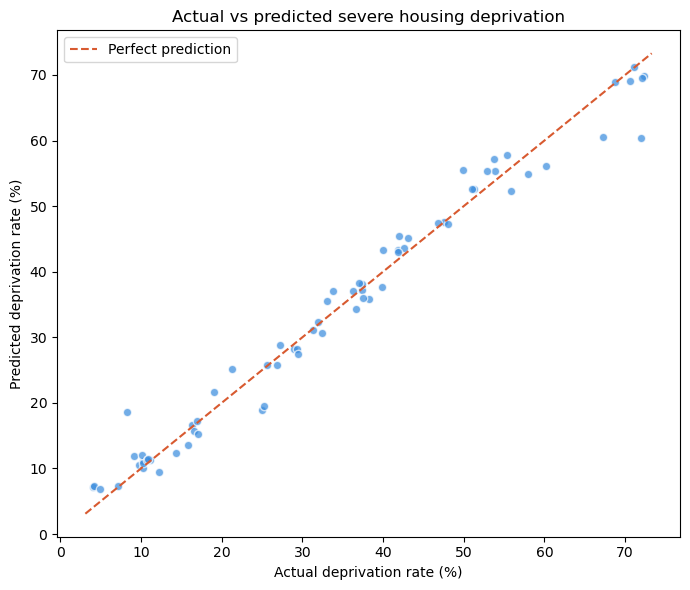

In [16]:
# plot 6: actual vs predicted deprivation rate

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color="#378ADD", edgecolors="white")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, "--", color="#D85A30", label="Perfect prediction")
ax.set_xlabel("Actual deprivation rate (%)")
ax.set_ylabel("Predicted deprivation rate (%)")
ax.set_title("Actual vs predicted severe housing deprivation")
ax.legend()
plt.tight_layout()
plt.show()

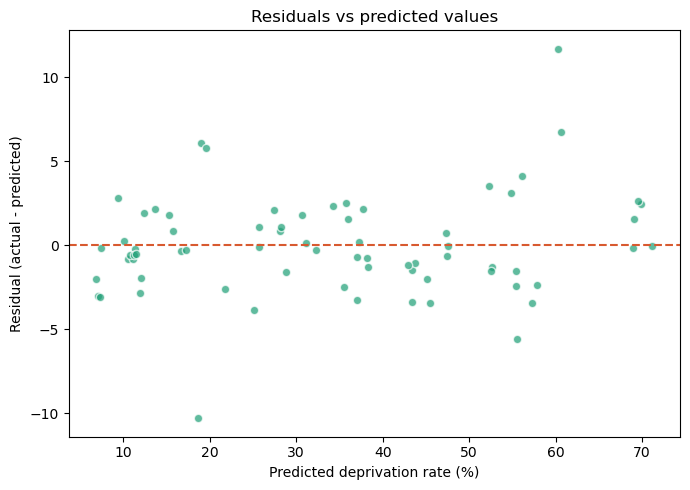

In [17]:
# plot 7: residuals -- should be randomly scattered around 0
# if there is a clear pattern, the linear model may be missing something

residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.7, color="#1D9E75", edgecolors="white")
ax.axhline(0, color="#D85A30", linestyle="--")
ax.set_xlabel("Predicted deprivation rate (%)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted values")
plt.tight_layout()
plt.show()

## 7. Interpret and Apply the Model

The coefficients tell us:
- `immigration_lag1`: whether last year's immigration inflow is associated with higher or lower deprivation this year
- `year`: whether deprivation is generally improving or worsening across Europe over time
- Country dummies: the baseline deprivation level for each country relative to the reference country

This ranking is what Emma would use to justify directing ESF+ funds to the highest-need countries.

In [18]:
# predict deprivation for the most recent year per country
# this is what would surface on Emma's dashboard

latest = (
    df.sort_values("year", ascending=False)
    .groupby("geo", as_index=False)
    .first()
)

X_latest_cont = scaler.transform(latest[continuous_cols].to_numpy())
X_latest_dum  = latest[dummy_cols].to_numpy().astype(float)
X_latest      = np.hstack([X_latest_cont, X_latest_dum])

n_latest   = X_latest.shape[0]
X_latest_b = np.column_stack([np.ones(n_latest), X_latest])
latest["predicted_deprivation"] = X_latest_b @ weights

result = (
    latest[["geo", "year", "deprivation_rate", "predicted_deprivation"]]
    .sort_values("predicted_deprivation", ascending=False)
)
print("Countries ranked by predicted deprivation (highest = most need for ESF+ funding):")
print(result.to_string(index=False))

Countries ranked by predicted deprivation (highest = most need for ESF+ funding):
            geo  year  deprivation_rate  predicted_deprivation
         Cyprus  2024              70.1              71.277865
          Malta  2024              62.9              70.438389
        Ireland  2024              66.8              69.519707
        Belgium  2024              57.9              61.316546
          Spain  2024              55.4              57.784989
    Netherlands  2024              58.7              56.109130
     Luxembourg  2024              57.5              55.823233
 United Kingdom  2018              55.8              54.898937
         Norway  2024              52.6              53.202253
        Finland  2024              46.9              48.373653
    Switzerland  2024              42.4              45.719428
        Denmark  2024              42.4              44.037021
         France  2024              40.0              43.381323
         Sweden  2024              3

In [19]:
# plot 8: predicted deprivation by country -- Emma's dashboard output

fig8 = px.bar(
    result.sort_values("predicted_deprivation"),
    x="predicted_deprivation", y="geo", orientation="h",
    title="Predicted severe housing deprivation by country",
    labels={"predicted_deprivation": "Predicted deprivation rate (%)", "geo": ""},
    color="predicted_deprivation", color_continuous_scale="Reds"
)
fig8.show()